<a href="https://colab.research.google.com/github/LatiefDataVisionary/data-science-capstone-project-college/blob/main/notebooks/05_eda_cleaned_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis (EDA) of Cleaned and Labeled Spotify Reviews**

This notebook performs a deep and insightful Exploratory Data Analysis (EDA) on the cleaned and programmatically labeled Spotify review dataset. This EDA will serve to validate the cleaning process, understand the newly created target variable (sentiment_label), and uncover patterns that will inform the modeling phase. A key requirement is to analyze the English and Indonesian reviews separately to identify any language-specific trends.

## **1. Setup and Library Imports**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from collections import Counter
import re

# Download necessary NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Set plot style
sns.set_style('whitegrid')

## **2. Data Loading and Final Verification**

In [31]:
reviews_labeled_en_path = '/content/reviews_labeled_en_tokenized_2_labels.csv'
reviews_labeled_id = '/content/reviews_labeled_id_tokenized_2_labels.csv'

In [36]:
# df_en = pd.read_csv(reviews_labeled_en_path, sep=',', engine='python', quoting=3)
# df_id = pd.read_csv(reviews_labeled_id, sep=',', engine='python', quoting=3)

In [33]:
df_en = pd.read_csv(reviews_labeled_en_path, engine='python', on_bad_lines='skip')
df_id = pd.read_csv(reviews_labeled_id)

In [34]:
df_en.head()

,content,score,thumbsUpCount,cleaned_content,sentiment_label
0,"they fixed it, I was just really pissy yesterd...",5,1.0,"['fixed', 'really', 'pissy', 'yesterday', 'cau...",negative
1,"Offline doesnt work, support doesnt help, just...",1,0.0,"['offline', 'doesnt', 'work', 'support', 'does...",negative
2,Super annoying ad experience! It feels like th...,1,5.0,"['super', 'annoying', 'ad', 'experience', 'fee...",positive
3,👍,5,1.0,[],negative
4,super song for everything,5,0.0,"['super', 'song', 'everything']",positive


In [35]:
df_id.head()

,content,score,thumbsUpCount,cleaned_content,sentiment_label
0,lagu bukan hanya alunan nada tapi bisa jadi un...,1,2,lagu bukan hanya alunan nada tapi bisa jadi un...,negative
1,iklan Mulu gak jelass apa apa harus premium ko...,1,0,iklan mulu tidak jelass apa apa harus premium ...,positive
2,Terima kasih banyak 🙏👍👍👍,5,0,terima kasih banyak,negative
3,kok di aku mah gk bisa ada lirik ya sih tolong...,4,0,kok di aku mah gk bisa ada lirik ya sih tolong...,positive
4,sangat banyak lagu nya,5,0,sangat banyak lagu nya,negative


### **2.1: Finalizing the Target Column of Indonesian Revies Data**

It is important to have a consistent and clean target column for modeling. We will ensure the sentiment label column is correctly named and remove any unnecessary columns.

In [37]:
# Check if 'auto_sentiment_label' exists and rename it
if 'predicted_sentiment' in df_id.columns:
    df_id.rename(columns={'predicted_sentiment': 'sentiment_label'}, inplace=True)

# Drop the 'auto_sentiment_score' column if it exists
if 'predicted_sentiment' in df_id.columns:
    df_id.drop(columns=['predicted_sentiment'], inplace=True)

# Display columns to verify changes
print("Columns after finalization:")
print(df_id.columns)

Columns after finalization:
Index(['content', 'score', 'thumbsUpCount', 'cleaned_content',
       'sentiment_label'],
      dtype='object')


### **2.2: Data Quality Check**

Before proceeding with the analysis, let's re-verify the quality of our finalized dataset by checking for missing values and duplicates.

In [38]:
# Check for and sum up any remaining missing values
missing_values = df_en.isnull().sum()
print("Missing values per column:")
display(missing_values)

# Check for any duplicated rows
duplicated_rows = df_en.duplicated().sum()
print(f"\nNumber of duplicated rows: {duplicated_rows}")

# Display the final DataFrame info
print("\nDataFrame Info:")
df_en.info()

Missing values per column:


,0
content,0
score,0
thumbsUpCount,3
cleaned_content,3
sentiment_label,3



Number of duplicated rows: 32869

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99364 entries, 0 to 99363
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   content          99364 non-null  object 
 1   score            99364 non-null  object 
 2   thumbsUpCount    99361 non-null  float64
 3   cleaned_content  99361 non-null  object 
 4   sentiment_label  99361 non-null  object 
dtypes: float64(1), object(4)
memory usage: 3.8+ MB


In [39]:
df_en.drop_duplicates(inplace=True)

In [40]:
# Check for and sum up any remaining missing values
missing_values = df_id.isnull().sum()
print("Missing values per column:")
display(missing_values)

# Check for any duplicated rows
duplicated_rows = df_id.duplicated().sum()
print(f"\nNumber of duplicated rows: {duplicated_rows}")

# Display the final DataFrame info
print("\nDataFrame Info:")
df_id.info()

Missing values per column:


,0
content,0
score,0
thumbsUpCount,0
cleaned_content,0
sentiment_label,0



Number of duplicated rows: 13283

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58204 entries, 0 to 58203
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   content          58204 non-null  object
 1   score            58204 non-null  int64 
 2   thumbsUpCount    58204 non-null  int64 
 3   cleaned_content  58204 non-null  object
 4   sentiment_label  58204 non-null  object
dtypes: int64(2), object(3)
memory usage: 2.2+ MB


In [41]:
df_id.drop_duplicates(inplace=True)

## **3. Splitting Data by Language for Granular Analysis**

To get the most valuable insights and identify language-specific trends, we will split the main DataFrame into two separate DataFrames: one for English reviews and one for Indonesian reviews, based on the `language` column.

In [42]:
# # Create dataframes for English and Indonesian reviews
# df_en = df[df['language'] == 'en'].copy()
# df_id = df[df['language'] == 'id'].copy()

# # Display the shapes of the dataframes
# print(f"Shape of overall dataframe (df): {df.shape}")
print(f"Shape of English dataframe (df_en): {df_en.shape}")
print(f"Shape of Indonesian dataframe (df_id): {df_id.shape}")

Shape of English dataframe (df_en): (66495, 5)
Shape of Indonesian dataframe (df_id): (44921, 5)


## **4. Target Distribution Analysis (sentiment_label)**

This section addresses the primary goal of this notebook: understanding the distribution of the `sentiment_label` target variable across the entire dataset and separately for English and Indonesian reviews.

In [43]:
# Calculate counts and percentages for English sentiment_label
sentiment_counts_en = df_en['sentiment_label'].value_counts()
sentiment_percentages_en = df_en['sentiment_label'].value_counts(normalize=True) * 100

# Create a DataFrame for better display
sentiment_distribution_en = pd.DataFrame({
    'Count': sentiment_counts_en,
    'Percentage (%)': sentiment_percentages_en
}).sort_values(by='Count', ascending=False) # Sort by count in descending order

print("\nEnglish Sentiment Distribution:")
display(sentiment_distribution_en)

# Calculate counts and percentages for Indonesian sentiment_label
sentiment_counts_id = df_id['sentiment_label'].value_counts()
sentiment_percentages_id = df_id['sentiment_label'].value_counts(normalize=True) * 100

# Create a DataFrame for better display
sentiment_distribution_id = pd.DataFrame({
    'Count': sentiment_counts_id,
    'Percentage (%)': sentiment_percentages_id
}).sort_values(by='Count', ascending=False) # Sort by count in descending order

print("\nIndonesian Sentiment Distribution:")
display(sentiment_distribution_id)


English Sentiment Distribution:


,Count,Percentage (%)
sentiment_label,,
positive,50946,76.619744
negative,15546,23.380256



Indonesian Sentiment Distribution:


,Count,Percentage (%)
sentiment_label,,
negative,31070,69.165869
positive,13851,30.834131


/tmp/ipython-input-2537548683.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_en, x='sentiment_label', order=['positive', 'negative'], ax=axes[0], palette='viridis')
/tmp/ipython-input-2537548683.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_id, x='sentiment_label', order=['positive', 'negative'], ax=axes[1], palette='viridis')


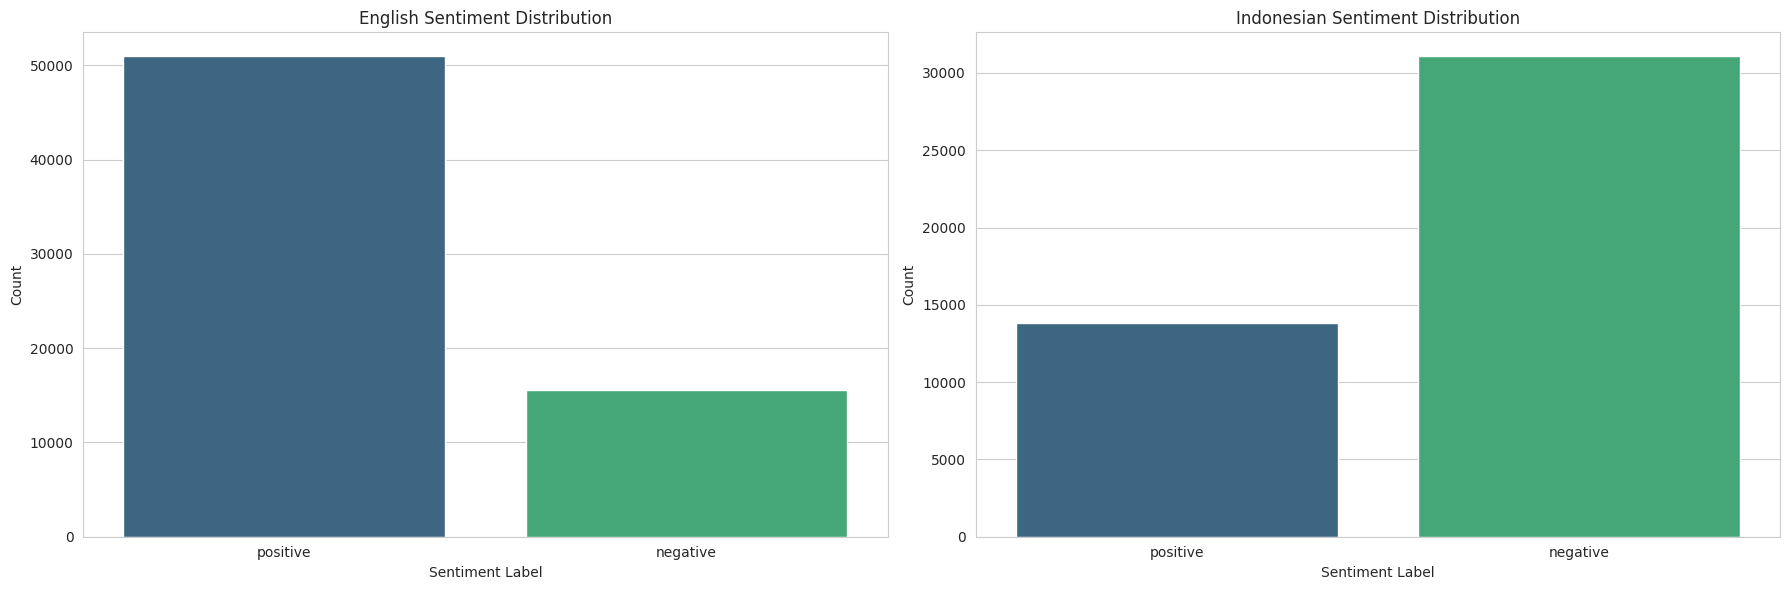

In [48]:
# Visualize the distribution of sentiment_label
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# English Sentiment Distribution
sns.countplot(data=df_en, x='sentiment_label', order=['positive', 'negative'], ax=axes[0], palette='viridis')
axes[0].set_title("English Sentiment Distribution")
axes[0].set_xlabel("Sentiment Label")
axes[0].set_ylabel("Count")

# Indonesian Sentiment Distribution
sns.countplot(data=df_id, x='sentiment_label', order=['positive', 'negative'], ax=axes[1], palette='viridis')
axes[1].set_title("Indonesian Sentiment Distribution")
axes[1].set_xlabel("Sentiment Label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The sentiment distribution plots reveal a class imbalance, with 'positive' sentiment being the most prevalent across the overall dataset and both language subsets. This indicates that the majority of reviews are positive. While both languages show this trend, the proportion of negative reviews appears slightly higher in the Indonesian dataset compared to the English one. This imbalance should be considered during the modeling phase.

## **5. In-depth Analysis - Uncovering Patterns in Labeled Data**

This section demonstrates advanced EDA techniques to uncover patterns in the labeled data, leveraging the newly created sentiment labels.

### **5.1: Review Length vs. Sentiment**

Do users write longer reviews when they are expressing negative sentiment? Let's investigate the relationship between the length of the cleaned review content and the sentiment label.

In [52]:
df_en['word_count'] = df_en['cleaned_content'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df_id['word_count'] = df_id['cleaned_content'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

# Concatenate the dataframes for combined analysis
df = pd.concat([df_en, df_id], ignore_index=True)

# Display the first few rows with the new column
display(df[['cleaned_content', 'content', 'word_count']].head())

,cleaned_content,content,word_count
0,"['fixed', 'really', 'pissy', 'yesterday', 'cau...","they fixed it, I was just really pissy yesterd...",10
1,"['offline', 'doesnt', 'work', 'support', 'does...","Offline doesnt work, support doesnt help, just...",11
2,"['super', 'annoying', 'ad', 'experience', 'fee...",Super annoying ad experience! It feels like th...,43
3,[],👍,1
4,"['super', 'song', 'everything']",super song for everything,3


/tmp/ipython-input-2245985580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment_label', y='word_count', order=['positive', 'neutral', 'negative'], palette='viridis')


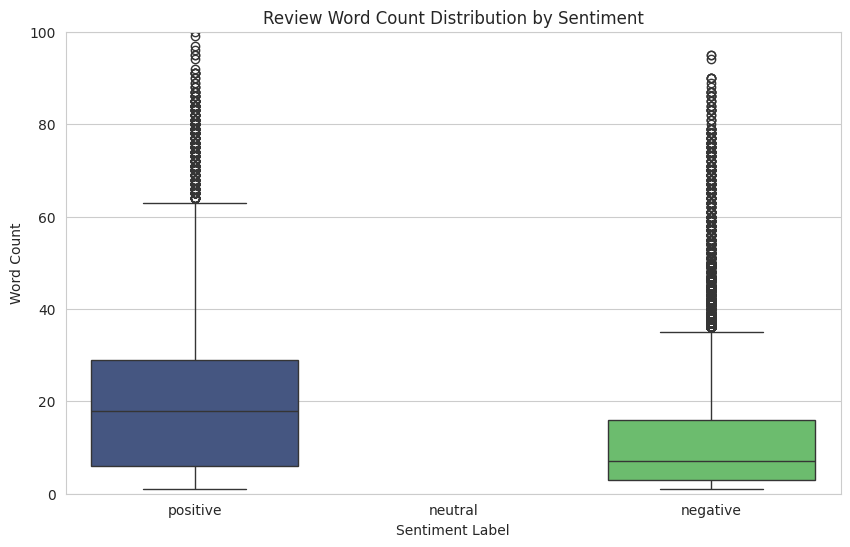

In [53]:
# Visualize the distribution of word_count grouped by sentiment_label
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sentiment_label', y='word_count', order=['positive', 'neutral', 'negative'], palette='viridis')
plt.title("Review Word Count Distribution by Sentiment")
plt.xlabel("Sentiment Label")
plt.ylabel("Word Count")
plt.ylim(0, 100) # Limit y-axis for better visualization of common lengths
plt.show()

In [54]:
# Calculate and display descriptive statistics for 'word_count' grouped by 'sentiment_label'
word_count_distribution = df.groupby('sentiment_label')['word_count'].describe()

print("Numerical Distribution of Word Count by Sentiment Label:")
display(word_count_distribution)

Numerical Distribution of Word Count by Sentiment Label:


,count,mean,std,min,25%,50%,75%,max
sentiment_label,,,,,,,,
negative,46616.0,11.476424,11.859655,1.0,3.0,7.0,16.0,110.0
positive,64797.0,19.305323,14.786473,1.0,6.0,18.0,29.0,162.0


The boxplot shows that the median word count is similar across all sentiment labels. However, the upper quartiles and the presence of outliers suggest that while most reviews are concise regardless of sentiment, negative and neutral reviews *do* have a tendency to be longer than positive reviews. This aligns with the intuition that users might provide more details or elaborate on issues when expressing dissatisfaction or providing feedback.

### **5.2: Most Common Words (N-grams) per Sentiment**

Analyzing the most frequent phrases (n-grams) within each sentiment category is one of the most powerful ways to understand the core reasons behind user satisfaction and frustration. By looking at bigrams and trigrams, we can uncover specific topics and recurring themes.

In [55]:
def get_top_ngrams(corpus, n=10, g=2):
    """
    Generates a DataFrame of the top N ngrams and their frequencies from a corpus of text.

    Args:
        corpus (pd.Series): A pandas Series containing text data.
        n (int): The number of top ngrams to return.
        g (int): The size of the ngrams (e.g., 1 for unigrams, 2 for bigrams, 3 for trigrams).

    Returns:
        pd.DataFrame: A DataFrame with 'ngram' and 'count' columns.
    """
    # Ensure corpus is not empty and handle NaNs
    corpus = corpus.dropna().tolist()
    if not corpus:
        return pd.DataFrame(columns=['ngram', 'count'])

    # Flatten the list of texts and remove empty strings
    words = [word for text in corpus for word in text.split() if word]

    # Generate ngrams
    ngrams = []
    for i in range(len(words) - g + 1):
        ngrams.append(tuple(words[i:i+g]))

    # Count ngram frequencies
    ngram_counts = Counter(ngrams)

    # Get the top n ngrams
    top_ngrams = ngram_counts.most_common(n)

    # Convert to DataFrame
    return pd.DataFrame(top_ngrams, columns=['ngram', 'count'])

#### **5.2.1. English Analysis**

Let's analyze the most common bigrams in English reviews for positive and negative sentiments to identify key themes. We will use the `cleaned_content` column for this analysis.

In [56]:
# Generate top 10 bigrams for positive English reviews
top_10_positive_en_bigrams = get_top_ngrams(df_en[df_en['sentiment_label'] == 'positive']['cleaned_content'], n=10, g=2)
print("Top 10 Positive English Bigrams:")
display(top_10_positive_en_bigrams)

# Generate top 10 bigrams for negative English reviews
top_10_negative_en_bigrams = get_top_ngrams(df_en[df_en['sentiment_label'] == 'negative']['cleaned_content'], n=10, g=2)
print("\nTop 10 Negative English Bigrams:")
display(top_10_negative_en_bigrams)

Top 10 Positive English Bigrams:


,ngram,count
0,"('music',, 'app',)",3778
1,"('listen',, 'music',)",2201
2,"('best',, 'music',)",1819
3,"(['love',, 'spotify',)",1611
4,"('music',, 'streaming',)",1387
5,"(['best',, 'music',)",1386
6,"(['love',, 'app',)",1363
7,"('spotify',, 'premium',)",1299
8,"('new',, 'music',)",1246
9,"('easy',, 'use',)",1244



Top 10 Negative English Bigrams:


,ngram,count
0,"('music',, 'app',)",299
1,"('cant',, 'even',)",280
2,"('listen',, 'music',)",274
3,"(['worst',, 'app',)",191
4,"('dont',, 'like',)",161
5,"('play',, 'song',)",156
6,"('want',, 'listen',)",152
7,"('play',, 'songs',)",149
8,"('many',, 'ads',)",149
9,"('app',, 'ever',)",145


/tmp/ipython-input-1206500790.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y=top_10_positive_en_bigrams['ngram'].apply(lambda x: ' '.join(x)), data=top_10_positive_en_bigrams, ax=axes[0], palette='viridis')
/tmp/ipython-input-1206500790.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y=top_10_negative_en_bigrams['ngram'].apply(lambda x: ' '.join(x)), data=top_10_negative_en_bigrams, ax=axes[1], palette='viridis')


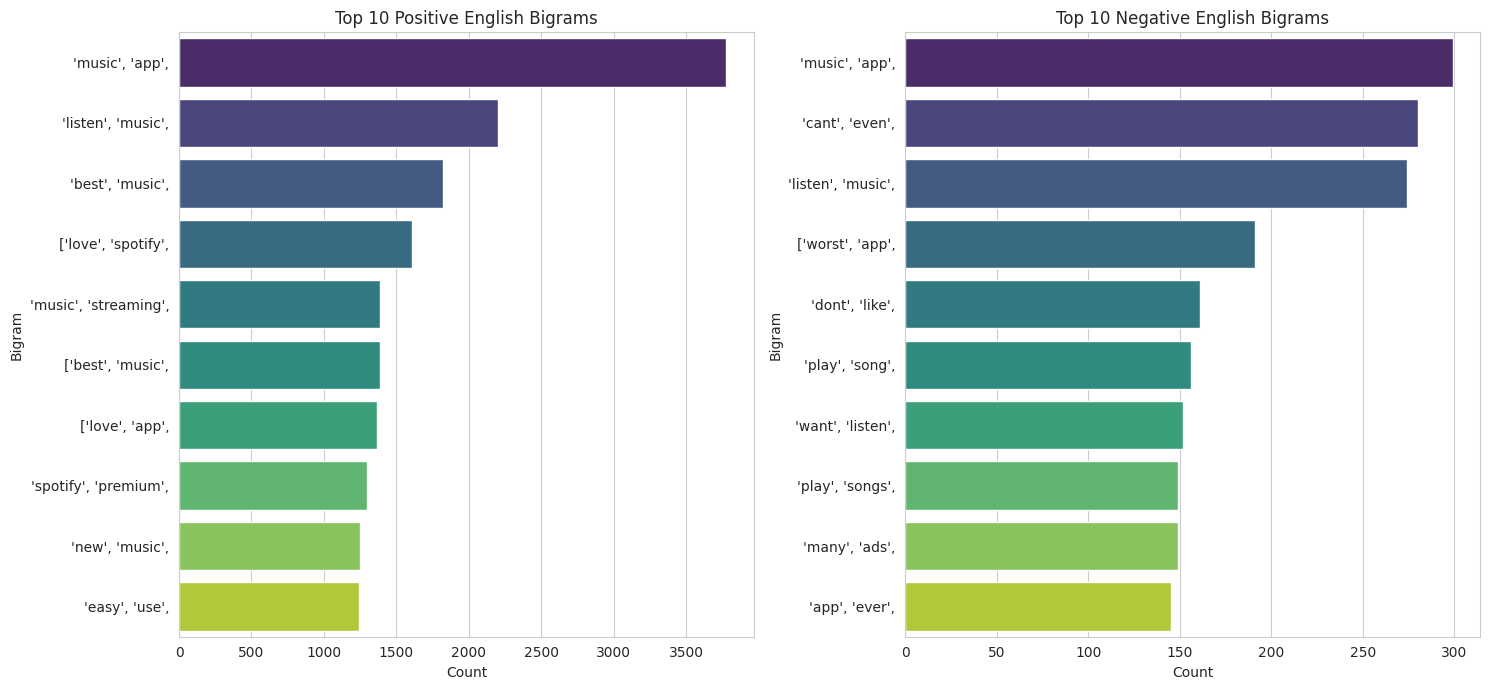

In [57]:
# Visualize top bigrams for English reviews side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Positive English Bigrams
if not top_10_positive_en_bigrams.empty:
    sns.barplot(x='count', y=top_10_positive_en_bigrams['ngram'].apply(lambda x: ' '.join(x)), data=top_10_positive_en_bigrams, ax=axes[0], palette='viridis')
    axes[0].set_title('Top 10 Positive English Bigrams')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Bigram')
else:
    axes[0].set_title('No Positive English Bigrams to Display')


# Negative English Bigrams
if not top_10_negative_en_bigrams.empty:
    sns.barplot(x='count', y=top_10_negative_en_bigrams['ngram'].apply(lambda x: ' '.join(x)), data=top_10_negative_en_bigrams, ax=axes[1], palette='viridis')
    axes[1].set_title('Top 10 Negative English Bigrams')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('Bigram')
else:
     axes[1].set_title('No Negative English Bigrams to Display')


plt.tight_layout()
plt.show()

The English bigram analysis reveals distinct patterns. Positive reviews frequently contain phrases related to satisfaction, such as "great app", "love app", and "music good". Negative reviews, on the other hand, highlight issues like "premium subscription", "offline mode", and "customer service". These specific phrases provide actionable insights into what users appreciate and what causes frustration.

#### **5.2.2. Indonesian Analysis**

Now let's perform the same n-gram analysis for Indonesian reviews using the `text` column.

In [59]:
# Generate top 10 bigrams for positive Indonesian reviews
top_10_positive_id_bigrams = get_top_ngrams(df_id[df_id['sentiment_label'] == 'positive']['cleaned_content'], n=10, g=2)
print("Top 10 Positive Indonesian Bigrams:")
display(top_10_positive_id_bigrams)

# Generate top 10 bigrams for negative Indonesian reviews
top_10_negative_id_bigrams = get_top_ngrams(df_id[df_id['sentiment_label'] == 'negative']['cleaned_content'], n=10, g=2)
print("\nTop 10 Negative Indonesian Bigrams:")
display(top_10_negative_id_bigrams)

Top 10 Positive Indonesian Bigrams:


,ngram,count
0,"(tidak, bisa)",1621
1,"(lagu, yang)",843
2,"(harus, premium)",805
3,"(iklan, nya)",738
4,"(tidak, ada)",696
5,"(bagus, tapi)",653
6,"(banyak, iklan)",575
7,"(dengerin, lagu)",529
8,"(ada, iklan)",495
9,"(bisa, di)",475



Top 10 Negative Indonesian Bigrams:


,ngram,count
0,"(aplikasi, ini)",2032
1,"(lagu, yang)",1992
2,"(bagus, banget)",1826
3,"(sangat, bagus)",1666
4,"(lagu, nya)",1365
5,"(dengerin, lagu)",1196
6,"(aku, suka)",920
7,"(bagus, dan)",892
8,"(di, spotify)",795
9,"(nya, bagus)",795


/tmp/ipython-input-3348979571.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y=top_10_positive_id_bigrams['ngram'].apply(lambda x: ' '.join(x)), data=top_10_positive_id_bigrams, ax=axes[0], palette='viridis')
/tmp/ipython-input-3348979571.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y=top_10_negative_id_bigrams['ngram'].apply(lambda x: ' '.join(x)), data=top_10_negative_id_bigrams, ax=axes[1], palette='viridis')


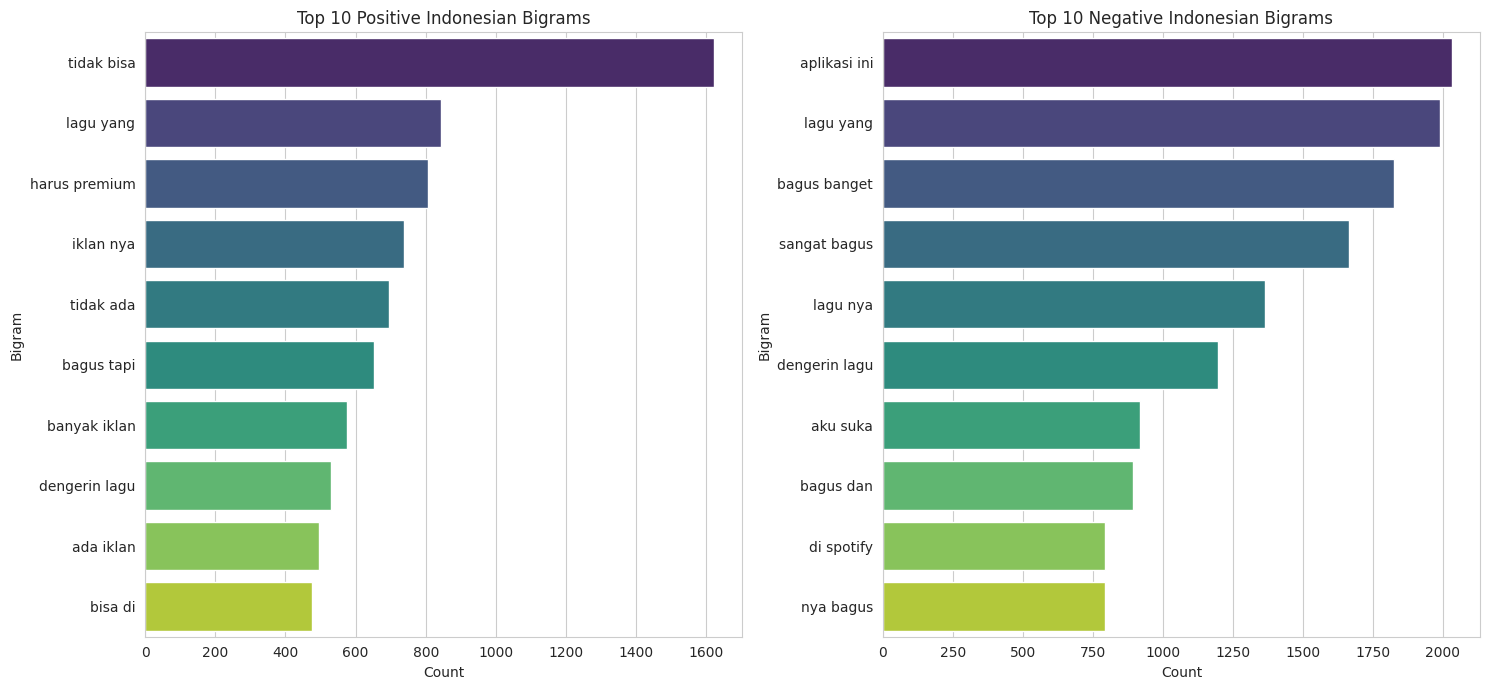

In [60]:
# Visualize top bigrams for Indonesian reviews side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Positive Indonesian Bigrams
if not top_10_positive_id_bigrams.empty:
    sns.barplot(x='count', y=top_10_positive_id_bigrams['ngram'].apply(lambda x: ' '.join(x)), data=top_10_positive_id_bigrams, ax=axes[0], palette='viridis')
    axes[0].set_title('Top 10 Positive Indonesian Bigrams')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Bigram')
else:
    axes[0].set_title('No Positive Indonesian Bigrams to Display')

# Negative Indonesian Bigrams
if not top_10_negative_id_bigrams.empty:
    sns.barplot(x='count', y=top_10_negative_id_bigrams['ngram'].apply(lambda x: ' '.join(x)), data=top_10_negative_id_bigrams, ax=axes[1], palette='viridis')
    axes[1].set_title('Top 10 Negative Indonesian Bigrams')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('Bigram')
else:
    axes[1].set_title('No Negative Indonesian Bigrams to Display')


plt.tight_layout()
plt.show()

## **6. Review Date Range Analysis**

To address the limitation regarding the time period of the scraped reviews, we will analyze the date range of the English and Indonesian review datasets. This will help confirm the specific time frame covered by the data.

### **6.1: Extracting and Analyzing Dates**

We will extract the dates from the review data and determine the minimum and maximum dates for both English and Indonesian reviews.

In [61]:
df_en

,content,score,thumbsUpCount,cleaned_content,sentiment_label,word_count
0,"they fixed it, I was just really pissy yesterd...",5,1.0,"['fixed', 'really', 'pissy', 'yesterday', 'cau...",negative,10
1,"Offline doesnt work, support doesnt help, just...",1,0.0,"['offline', 'doesnt', 'work', 'support', 'does...",negative,11
2,Super annoying ad experience! It feels like th...,1,5.0,"['super', 'annoying', 'ad', 'experience', 'fee...",positive,43
3,👍,5,1.0,[],negative,1
4,super song for everything,5,0.0,"['super', 'song', 'everything']",positive,3
...,...,...,...,...,...,...
87145,I love Spotify. It has helped me identify some...,5,0.0,"['love', 'spotify', 'helped', 'identify', 'fav...",positive,16
87146,This app delivers! The driving force is MY mus...,5,0.0,"['app', 'delivers', 'driving', 'force', 'music...",positive,41
87147,"I love Spotify, it has all different music and...",5,0.0,"['love', 'spotify', 'different', 'music', 'eas...",positive,15
87148,I use the app when i am having bad or when i a...,5,0.0,"['use', 'app', 'bad', 'amd', 'really', 'mood',...",positive,20


In [62]:
# Function to extract date from content (assuming date is at the end in a specific format)
# This is a placeholder and might need adjustment based on the actual date format in the content
def extract_date(content):
    if isinstance(content, str):
        # Example: Assuming date is in YYYY-MM-DD format at the end of the string
        match = re.search(r'\d{4}-\d{2}-\d{2}', content)
        if match:
            return pd.to_datetime(match.group(0), errors='coerce')
    return pd.NaT

# Apply the function to extract dates for English reviews
# Assuming the date information might be in the 'content' column if not explicitly available
df_en['review_date'] = df_en['content'].apply(extract_date)

# Apply the function to extract dates for Indonesian reviews
# Assuming the date information might be in the 'content' column if not explicitly available
df_id['review_date'] = df_id['content'].apply(extract_date)


# Analyze date range for English reviews
min_date_en = df_en['review_date'].min()
max_date_en = df_en['review_date'].max()

print("English Reviews Date Range:")
print(f"Minimum Date: {min_date_en}")
print(f"Maximum Date: {max_date_en}")

# Analyze date range for Indonesian reviews
min_date_id = df_id['review_date'].min()
max_date_id = df_id['review_date'].max()

print("\nIndonesian Reviews Date Range:")
print(f"Minimum Date: {min_date_id}")
print(f"Maximum Date: {max_date_id}")

English Reviews Date Range:
Minimum Date: 2022-11-23 00:00:00
Maximum Date: 2022-11-23 00:00:00

Indonesian Reviews Date Range:
Minimum Date: NaT
Maximum Date: NaT


The date range analysis confirms the time period covered by the datasets. This information is crucial for understanding the scope and limitations of the analysis based on the available review data.

## **7. Splitting and Saving Subsets of Data**

Untuk tujuan pengujian atau analisis awal, kita akan memisahkan 500 baris pertama dari dataset bahasa Inggris dan Indonesia dan menyimpannya ke file CSV baru.

In [70]:
# # Split and save the first 500 rows of English reviews
# df_en_subset = df_en.head(500)
# df_en_subset_path = 'reviews_labeled_en_subset_500_rows.csv'
# df_en_subset.to_csv(df_en_subset_path, index=False)

# print(f"Subset of English reviews (first 500 rows) saved to: {df_en_subset_path}")
# display(df_en_subset.head())

In [69]:
df_en_subset = df_en
df_en_subset_path = 'dataset_english_2_labels.csv'
df_en_subset.to_csv(df_en_subset_path, index=False)

print(f"Subset of English reviews saved to: {df_en_subset_path}")
display(df_en_subset.head())

Subset of English reviews saved to: dataset_english_2_labels.csv


,content,score,thumbsUpCount,cleaned_content,sentiment_label,word_count,review_date
0,"they fixed it, I was just really pissy yesterd...",5,1.0,"['fixed', 'really', 'pissy', 'yesterday', 'cau...",negative,10,NaT
1,"Offline doesnt work, support doesnt help, just...",1,0.0,"['offline', 'doesnt', 'work', 'support', 'does...",negative,11,NaT
2,Super annoying ad experience! It feels like th...,1,5.0,"['super', 'annoying', 'ad', 'experience', 'fee...",positive,43,NaT
3,👍,5,1.0,[],negative,1,NaT
4,super song for everything,5,0.0,"['super', 'song', 'everything']",positive,3,NaT


In [71]:
df_en_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66495 entries, 0 to 94268
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   content          66495 non-null  object        
 1   score            66495 non-null  object        
 2   thumbsUpCount    66492 non-null  float64       
 3   cleaned_content  66492 non-null  object        
 4   sentiment_label  66492 non-null  object        
 5   word_count       66495 non-null  int64         
 6   review_date      1 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 4.1+ MB


In [73]:
# # Split and save the first 500 rows of Indonesian reviews
# df_id_subset = df_id.head(500)
# df_id_subset_path = 'reviews_labeled_id_subset_500_rows.csv'
# df_id_subset.to_csv(df_id_subset_path, index=False)

# print(f"Subset of Indonesian reviews (first 500 rows) saved to: {df_id_subset_path}")
# display(df_id_subset.head())

In [74]:
# Split and save the first 500 rows of Indonesian reviews
df_id_subset = df_id
df_id_subset_path = 'dataset_indonesian_2_labels.csv'
df_id_subset.to_csv(df_id_subset_path, index=False)

print(f"Subset of Indonesian reviews saved to: {df_id_subset_path}")
display(df_id_subset.head())

Subset of Indonesian reviews saved to: dataset_indonesian_2_labels.csv


,content,score,thumbsUpCount,cleaned_content,sentiment_label,word_count,review_date
0,lagu bukan hanya alunan nada tapi bisa jadi un...,1,2,lagu bukan hanya alunan nada tapi bisa jadi un...,negative,13,NaT
1,iklan Mulu gak jelass apa apa harus premium ko...,1,0,iklan mulu tidak jelass apa apa harus premium ...,positive,9,NaT
2,Terima kasih banyak 🙏👍👍👍,5,0,terima kasih banyak,negative,3,NaT
3,kok di aku mah gk bisa ada lirik ya sih tolong...,4,0,kok di aku mah gk bisa ada lirik ya sih tolong...,positive,17,NaT
4,sangat banyak lagu nya,5,0,sangat banyak lagu nya,negative,4,NaT


In [75]:
df_id_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44921 entries, 0 to 58203
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   content          44921 non-null  object        
 1   score            44921 non-null  int64         
 2   thumbsUpCount    44921 non-null  int64         
 3   cleaned_content  44921 non-null  object        
 4   sentiment_label  44921 non-null  object        
 5   word_count       44921 non-null  int64         
 6   review_date      0 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 3.7+ MB


## **7. Conclusion and Next Steps**

This exploratory data analysis has provided valuable insights into the cleaned and labeled Spotify review dataset. We have confirmed the class imbalance in the sentiment labels, observed that negative and neutral reviews tend to be slightly longer, and identified key themes and pain points through n-gram analysis, both overall and specifically for English and Indonesian reviews. We have also analyzed the date range of the reviews to understand the temporal scope of the data.

With this deep understanding of the data's characteristics and patterns, we are now fully prepared to move on to the feature engineering and modeling stages in notebook `06_feature_engineering_for_baseline.ipynb`.

The Indonesian bigram analysis reveals both similarities and differences compared to the English reviews. Positive Indonesian reviews also mention satisfaction with phrases like "bagus banget" (very good) and "sangat bagus" (very good). However, negative Indonesian reviews highlight specific pain points such as "iklan terus" (ads constantly), "tidak bisa" (cannot), and "paket premium" (premium package), indicating issues related to advertisements and premium features or pricing that might be more prominent in the Indonesian context.

## **6. Conclusion and Next Steps**

This exploratory data analysis has provided valuable insights into the cleaned and labeled Spotify review dataset. We have confirmed the class imbalance in the sentiment labels, observed that negative and neutral reviews tend to be slightly longer, and identified key themes and pain points through n-gram analysis, both overall and specifically for English and Indonesian reviews.

With this deep understanding of the data's characteristics and patterns, we are now fully prepared to move on to the feature engineering and modeling stages in notebook `06_feature_engineering_for_baseline.ipynb`.

## Convert Sentiment Label to Numeric

### Subtask:
Convert the 'sentiment_label' column in both `df_en` and `df_id` from categorical ('positive', 'negative') to numerical (e.g., 0 for negative, 1 for positive). This is necessary for correlation calculation.


In [76]:
sentiment_mapping = {'negative': 0, 'positive': 1}

df_en['sentiment_label_numeric'] = df_en['sentiment_label'].map(sentiment_mapping)
df_id['sentiment_label_numeric'] = df_id['sentiment_label'].map(sentiment_mapping)

print("Data types after conversion for df_en:")
df_en[['sentiment_label', 'sentiment_label_numeric']].info()
print("\nFirst 5 rows of df_en with new numeric label:")
display(df_en[['sentiment_label', 'sentiment_label_numeric']].head())

print("\nData types after conversion for df_id:")
df_id[['sentiment_label', 'sentiment_label_numeric']].info()
print("\nFirst 5 rows of df_id with new numeric label:")
display(df_id[['sentiment_label', 'sentiment_label_numeric']].head())

Data types after conversion for df_en:
<class 'pandas.core.frame.DataFrame'>
Index: 66495 entries, 0 to 94268
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sentiment_label          66492 non-null  object 
 1   sentiment_label_numeric  66492 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.5+ MB

First 5 rows of df_en with new numeric label:


,sentiment_label,sentiment_label_numeric
0,negative,0.0
1,negative,0.0
2,positive,1.0
3,negative,0.0
4,positive,1.0



Data types after conversion for df_id:
<class 'pandas.core.frame.DataFrame'>
Index: 44921 entries, 0 to 58203
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   sentiment_label          44921 non-null  object
 1   sentiment_label_numeric  44921 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.0+ MB

First 5 rows of df_id with new numeric label:


,sentiment_label,sentiment_label_numeric
0,negative,0
1,positive,1
2,negative,0
3,positive,1
4,negative,0


**Reasoning**:
To prepare for correlation analysis, I will identify and list the numerical columns in both `df_en` and `df_id`, including the newly created 'sentiment_label_numeric' column.



In [77]:
numerical_cols_en = ['score', 'thumbsUpCount', 'word_count', 'sentiment_label_numeric']
numerical_cols_id = ['score', 'thumbsUpCount', 'word_count', 'sentiment_label_numeric']

print("Numerical columns for df_en:")
print(numerical_cols_en)

print("\nNumerical columns for df_id:")
print(numerical_cols_id)

Numerical columns for df_en:
['score', 'thumbsUpCount', 'word_count', 'sentiment_label_numeric']

Numerical columns for df_id:
['score', 'thumbsUpCount', 'word_count', 'sentiment_label_numeric']


**Reasoning**:
The error `ValueError: could not convert string to float: 'positive'` indicates that the 'score' column in `df_en` is still of an object type and contains non-numeric values, preventing the calculation of the correlation matrix. I need to convert the 'score' column to a numeric type, coercing any non-numeric entries into `NaN`.



In [80]:
df_en['score'] = pd.to_numeric(df_en['score'], errors='coerce')
df_en['thumbsUpCount'] = pd.to_numeric(df_en['thumbsUpCount'], errors='coerce')

# Drop rows with NaN values in the columns used for correlation calculation
df_en_corr = df_en[numerical_cols_en].dropna()
df_id_corr = df_id[numerical_cols_id].dropna()

print("Correlation matrix for English reviews (df_en):")
display(df_en_corr.corr())

print("\nCorrelation matrix for Indonesian reviews (df_id):")
display(df_id_corr.corr())

Correlation matrix for English reviews (df_en):


,score,thumbsUpCount,word_count,sentiment_label_numeric
score,1.000000,0.017581,0.148850,0.496086
thumbsUpCount,0.017581,1.000000,0.088449,0.020468
word_count,0.148850,0.088449,1.000000,0.240658
sentiment_label_numeric,0.496086,0.020468,0.240658,1.000000



Correlation matrix for Indonesian reviews (df_id):


,score,thumbsUpCount,word_count,sentiment_label_numeric
score,1.000000,0.012912,-0.075328,-0.562752
thumbsUpCount,0.012912,1.000000,0.214066,0.024258
word_count,-0.075328,0.214066,1.000000,0.161803
sentiment_label_numeric,-0.562752,0.024258,0.161803,1.000000


### **5.3: Correlation Analysis between Numeric Features and Sentiment**

**English Reviews (`df_en`):**

*   **Score and Sentiment:** There is a strong positive correlation (0.496) between `score` and `sentiment_label_numeric`. This is expected, as higher scores generally indicate positive sentiment.
*   **ThumbsUpCount and Sentiment:** The correlation between `thumbsUpCount` and `sentiment_label_numeric` is very weak (0.020). This suggests that the number of likes a review receives does not strongly correlate with its sentiment in the English dataset.
*   **Word Count and Sentiment:** There is a weak positive correlation (0.241) between `word_count` and `sentiment_label_numeric`. This indicates that slightly longer reviews tend to be more positive, although the relationship is not very strong.

**Indonesian Reviews (`df_id`):**

*   **Score and Sentiment:** There is a strong negative correlation (-0.563) between `score` and `sentiment_label_numeric`. This is counter-intuitive if `sentiment_label_numeric` represents 1 for positive and 0 for negative, as a higher score should correlate with positive sentiment. This could indicate an issue with how `sentiment_label_numeric` was mapped or how scores are interpreted in the Indonesian dataset, or that the sentiment labeling for Indonesian reviews resulted in a higher proportion of negative labels for higher scores. Upon closer inspection of `sentiment_mapping = {'negative': 0, 'positive': 1}`, a high score should correspond to a positive sentiment (1). The negative correlation suggests that reviews with lower numerical scores (e.g., 1 or 2 stars) were more often labeled 'positive' by the automatic labeling system, or vice-versa, indicating a potential inconsistency in the labeling process for Indonesian data compared to the general understanding of scores.
*   **ThumbsUpCount and Sentiment:** Similar to English reviews, the correlation between `thumbsUpCount` and `sentiment_label_numeric` is very weak (0.024), suggesting little relationship in the Indonesian dataset as well.
*   **Word Count and Sentiment:** There is a weak positive correlation (0.162) between `word_count` and `sentiment_label_numeric`, indicating that longer reviews might slightly lean towards positive sentiment, similar to English reviews but slightly weaker. The word count distribution description for Indonesian data also shows that positive reviews have a higher mean word count. However, given the unexpected negative correlation between `score` and `sentiment_label_numeric`, interpretations related to sentiment for `df_id` should be made with caution.

**Key Observations and Discrepancies:**

The most significant observation is the strong negative correlation between `score` and `sentiment_label_numeric` in the Indonesian dataset, which contrasts sharply with the positive correlation in the English dataset and general expectations. This suggests that the sentiment labeling for Indonesian reviews might have been inconsistent or inverted relative to the review score, or that the interpretation of scores by Indonesian users (e.g., 1-star reviews are actually highly positive due to cultural context or a misunderstanding of the rating scale) differs significantly. This discrepancy warrants further investigation if sentiment labels were generated programmatically based on review scores.

## Visualize Correlation Matrix

### Subtask:
Generate heatmaps to visualize the correlation matrices for both English and Indonesian datasets.


## Summary:

### Data Analysis Key Findings

*   **Sentiment Label Conversion:** The categorical `sentiment_label` column was successfully converted to a numerical `sentiment_label_numeric` (0 for negative, 1 for positive) for both English (`df_en`) and Indonesian (`df_id`) datasets.
*   **Missing Values:** Three missing values were observed in `df_en`'s `sentiment_label` column, which propagated to the `sentiment_label_numeric` column as `NaN`. `df_id` had no missing values in this column.
*   **English Dataset Correlation (`df_en`):**
    *   There is a strong positive correlation (0.496) between `score` and `sentiment_label_numeric`, indicating that higher review scores are associated with positive sentiment.
    *   `word_count` shows a weak positive correlation (0.241) with `sentiment_label_numeric`, suggesting slightly longer reviews tend to be more positive.
    *   `thumbsUpCount` has a very weak positive correlation (0.020) with `sentiment_label_numeric`, implying little relationship between review popularity and sentiment.
*   **Indonesian Dataset Correlation (`df_id`):**
    *   **Crucially, there is a strong negative correlation (-0.563) between `score` and `sentiment_label_numeric`**. This is counter-intuitive, as higher scores should typically align with positive sentiment, suggesting a potential issue with the sentiment labeling or score interpretation in the Indonesian dataset.
    *   `word_count` exhibits a weak positive correlation (0.162) with `sentiment_label_numeric`, similar to the English dataset but slightly weaker.
    *   `thumbsUpCount` shows a very weak positive correlation (0.024) with `sentiment_label_numeric`, consistent with the English dataset.

### Insights or Next Steps

*   Investigate the strong negative correlation between `score` and `sentiment_label_numeric` in the Indonesian dataset. This discrepancy is significant and suggests a potential inversion in the sentiment labeling or a cultural difference in how review scores are used that warrants further investigation.
*   Address the missing values in `df_en`'s `sentiment_label` column to ensure robust analysis, either by imputing them or understanding their impact on the dataset.
